In [1]:
import os

import numpy as np
import optuna
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.preprocessing import MinMaxScaler, StandardScaler, FunctionTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

scaler = MinMaxScaler()

/home/jakob/.pyenv/versions/3.13.12/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def train_one_epoch(model, train_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for images_loaded, prices_loaded, tokens_loaded, ratings_loaded in train_loader:
        images_temp = images_loaded.float().to(device)
        prices_temp = prices_loaded.float().unsqueeze(1).to(device)
        tokens_temp = tokens_loaded.float().to(device)
        ratings_temp = ratings_loaded.float().unsqueeze(1).to(device)

        preds = model(images_temp, prices_temp, tokens_temp)
        loss = criterion(preds, ratings_temp)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

def evaluate_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for images_loaded, prices_loaded, tokens_loaded, ratings_loaded in loader:
            images_temp = images_loaded.float().to(device)
            prices_temp = prices_loaded.float().unsqueeze(1).to(device)
            tokens_temp = tokens_loaded.float().to(device)
            ratings_temp = ratings_loaded.float().unsqueeze(1).to(device)

            preds = model(images_temp, prices_temp, tokens_temp)
            loss = criterion(preds, ratings_temp)
            total_loss += loss.item()

    return total_loss / len(loader)


class ImagePriceRatingDataset(Dataset):
    def __init__(self, ratings, images, prices, tokens):
        if not (len(ratings) == len(images) == len(prices) == len(tokens)):
            raise ValueError("ratings, images, prices and tokens must have equal length")
        self.ratings = ratings
        self.images = images
        self.prices = prices
        self.tokens = tokens

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return self.images[idx], self.prices[idx], self.tokens[idx], self.ratings[idx]
    


In [3]:
# Find unique entries
unique_path = r"../data/grand_scraper_folder/unique_scrandle_cases_FULL.csv"
unique_dataframe = pd.read_csv(unique_path)
unique_entries = [unique_dataframe["occurrences"][i].split("|")[0].split(" ")[0] + ".webp" for i in range(len(unique_dataframe["occurrences"]))]

In [4]:
#Next, we´ll get the low-res photos imported(doesnt take long. for my computer: 7.5s)

#Creating a list for the photos with the corresponding dates and image names as well(crude way of being able to see which are outliers.
#Needs to be done better, really. If someone has the time, feel free to find a better way of doing things)
images_raw = []

#Next, a list for the metadata i want(for now, at least. there´s certainly going to be a better way of doing this later):
metadata_raw = []
tokendata_raw = []

#Folder with folders of images:
base_folder = r"../data/scran_sized_low_res_data"
#Meta data folders(yes, a bit inefficient. CHANGE LATER):
meta_folder = r"../data/grand_scraper_folder/scrandle_data"
current_folder = None


#Looping over all dates in the listed directory/folder:
for entry in sorted(unique_entries):
    date, image_placement = entry.split(":")
    
    #Finding a new date folder to check
    date_path = os.path.join(base_folder, date)
    meta_date_path = os.path.join(meta_folder, date)
    #Checking if the date path exists
    if not os.path.isdir(date_path):
        continue

    #print(f"Processing {entry}")
    
    #Reading entry image:
    image_path = os.path.join(date_path, image_placement)
    images_raw.append({
                    "date": date,
                    "image_name": image_placement,
                    "RGB": plt.imread(image_path, format="webp"),
                })

    if current_folder != date:
        current_folder = date
        meta_path = os.path.join(meta_folder, date, "meta.csv")
        meta_intermediate = pd.read_csv(meta_path)
        meta_tokens = pd.read_csv(meta_path,sep=",").fillna("")
        
        
    entry_row = meta_intermediate.loc[meta_intermediate["image_name"] == image_placement]
    metadata_raw.append({
                "price": entry_row["price"],
                "rating": entry_row["rating"],
                "year": entry_row["year"],
                "date": entry_row["date"],
                "image_name": entry_row["image_name"],
                "title": entry_row["title"],
                "subtitle": entry_row["subtitle"],
                "club": entry_row["club"],
                "country": entry_row["country"],
            })
    tokendata_raw.append(f"{entry_row["title"].iloc[0]} {entry_row["subtitle"].iloc[0]} {entry_row["country"].iloc[0]} {entry_row["club"].iloc[0]}")

In [5]:
ratings = []
for i in range(len(metadata_raw)):
    ratings += metadata_raw[i]["rating"].to_list()
ratings = torch.tensor(ratings) / 100

prices = []
for i in range(len(metadata_raw)):
    prices += metadata_raw[i]["price"].to_list()
prices = np.array(prices)
nan_mask = prices != prices
prices[nan_mask] = 0.0
prices = torch.tensor(scaler.fit_transform(prices.reshape(-1, 1)).ravel())

vectorizer = CountVectorizer()
tokens_csr = vectorizer.fit_transform(tokendata_raw)
tokens = torch.tensor(tokens_csr.toarray(), dtype=torch.float32) / 3.0

images = np.stack([img["RGB"] for img in images_raw]).astype(np.float32)
images = torch.from_numpy(images) / 255.0
images = images.permute(0,3,1,2)

In [ ]:
class ImagePriceRatingDataset(Dataset):
    def __init__(self, ratings, images, prices, tokens):
        if not (len(ratings) == len(images) == len(prices) == len(tokens)):
            raise ValueError("ratings, images, prices and tokens must have equal length")
        self.ratings = ratings
        self.images = images
        self.prices = prices
        self.tokens = tokens

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return self.images[idx], self.prices[idx], self.tokens[idx], self.ratings[idx]

n_tokens = tokens.shape[1]
class ImagePriceModel(nn.Module):
    def __init__(self, token_dim=n_tokens):
        super().__init__()
        weights = ResNet50_Weights.IMAGENET1K_V2
        image_branch = resnet50(weights=weights)
        self.image_branch = nn.Sequential(*list(image_branch.children())[:-1])  # 2048 features

        self.price_branch = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
        )

        self.token_branch = nn.Sequential(
            nn.Linear(token_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 128),
            nn.ReLU(),
        )

        joint_dim = 2048 + 16 + 128
        self.head = nn.Sequential(
            nn.Linear(joint_dim, 1024),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, image, price, token):
        img_feat = self.image_branch(image).flatten(1)      # [B, 2048]
        price_feat = self.price_branch(price)                # [B, 16]
        token_feat = self.token_branch(token)                # [B, 128]
        x = torch.cat([img_feat, price_feat, token_feat], dim=1)
        return self.head(x)

dataset = ImagePriceRatingDataset(ratings, images, prices, tokens)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(
    dataset, [train_size, test_size], generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using Device: {device}")

model = ImagePriceModel().to(device)
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)




# training loop (replace existing loop with this)
for epoch in range(10):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = evaluate_loss(model, test_loader, criterion, device)
    print(f"epoch {epoch+1}: train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

Using Device: cuda
epoch 1: train_loss=0.1849 | val_loss=0.1757
epoch 2: train_loss=0.1388 | val_loss=0.1238
epoch 3: train_loss=0.1027 | val_loss=0.1026
epoch 4: train_loss=0.0853 | val_loss=0.0980
epoch 5: train_loss=0.0773 | val_loss=0.1019
epoch 6: train_loss=0.0683 | val_loss=0.0877
epoch 7: train_loss=0.0638 | val_loss=0.0837
epoch 8: train_loss=0.0592 | val_loss=0.0769
epoch 9: train_loss=0.0583 | val_loss=0.0784
epoch 10: train_loss=0.0568 | val_loss=0.1197


In [27]:
epochs = [10, 5, 2]
learning_rates = [1e-4, 1e-5, 5e-7]


for i in range(len(epochs)):
    print(f"Initiating Fine Grid Level {i+1} |  Epochs: {epochs[i]} | Learning Rate: {learning_rates[i]}")
    optimizer_fine = torch.optim.Adam(model.parameters(), lr=learning_rates[i])

    for epoch in range(epochs[i]):
        train_loss = train_one_epoch(model, train_loader, optimizer_fine, criterion, device)
        val_loss = evaluate_loss(model, test_loader, criterion, device)
        print(f"epoch {epoch+1}: train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")



Initiating Fine Grid Level 1 |  Epochs: 10 | Learning Rate: 0.0001
epoch 1: train_loss=0.0485 | val_loss=0.0663
epoch 2: train_loss=0.0434 | val_loss=0.0628
epoch 3: train_loss=0.0404 | val_loss=0.0627
epoch 4: train_loss=0.0376 | val_loss=0.0598
epoch 5: train_loss=0.0368 | val_loss=0.0585
epoch 6: train_loss=0.0359 | val_loss=0.0608
epoch 7: train_loss=0.0355 | val_loss=0.0586
epoch 8: train_loss=0.0350 | val_loss=0.0553
epoch 9: train_loss=0.0360 | val_loss=0.0591
epoch 10: train_loss=0.0350 | val_loss=0.0562
Initiating Fine Grid Level 2 |  Epochs: 5 | Learning Rate: 1e-05
epoch 1: train_loss=0.0344 | val_loss=0.0565
epoch 2: train_loss=0.0341 | val_loss=0.0580
epoch 3: train_loss=0.0340 | val_loss=0.0565
epoch 4: train_loss=0.0340 | val_loss=0.0560
epoch 5: train_loss=0.0335 | val_loss=0.0556
Initiating Fine Grid Level 3 |  Epochs: 2 | Learning Rate: 5e-07
epoch 1: train_loss=0.0333 | val_loss=0.0545
epoch 2: train_loss=0.0329 | val_loss=0.0554


In [32]:
torch.save(model.state_dict(), "model_weights")

In [ ]:
model.eval()

preds_train = []
trues_train = []

with torch.no_grad():
    for images_loaded, prices_loaded, tokens_loaded, ratings_loaded in train_loader:
        images_loaded = images_loaded.to(device)
        prices_loaded = prices_loaded.float().unsqueeze(1).to(device)
        tokens_loaded = tokens_loaded.to(device)
        outputs = model(images_loaded, prices_loaded, tokens_loaded).squeeze(1)

        preds_train.append(outputs.cpu())
        trues_train.append(ratings_loaded.cpu())

preds_train = torch.cat(preds_train).numpy()
trues_train = torch.cat(trues_train).numpy()


preds_test = []
trues_test = []

with torch.no_grad():
    for images_loaded, prices_loaded, tokens_loaded, ratings_loaded in test_loader:
        images_loaded = images_loaded.to(device)
        prices_loaded = prices_loaded.float().unsqueeze(1).to(device)
        tokens_loaded = tokens_loaded.to(device)
        outputs = model(images_loaded, prices_loaded, tokens_loaded).squeeze(1)

        preds_test.append(outputs.cpu())
        trues_test.append(ratings_loaded.cpu())

preds_test = torch.cat(preds_test).numpy()
trues_test = torch.cat(trues_test).numpy()


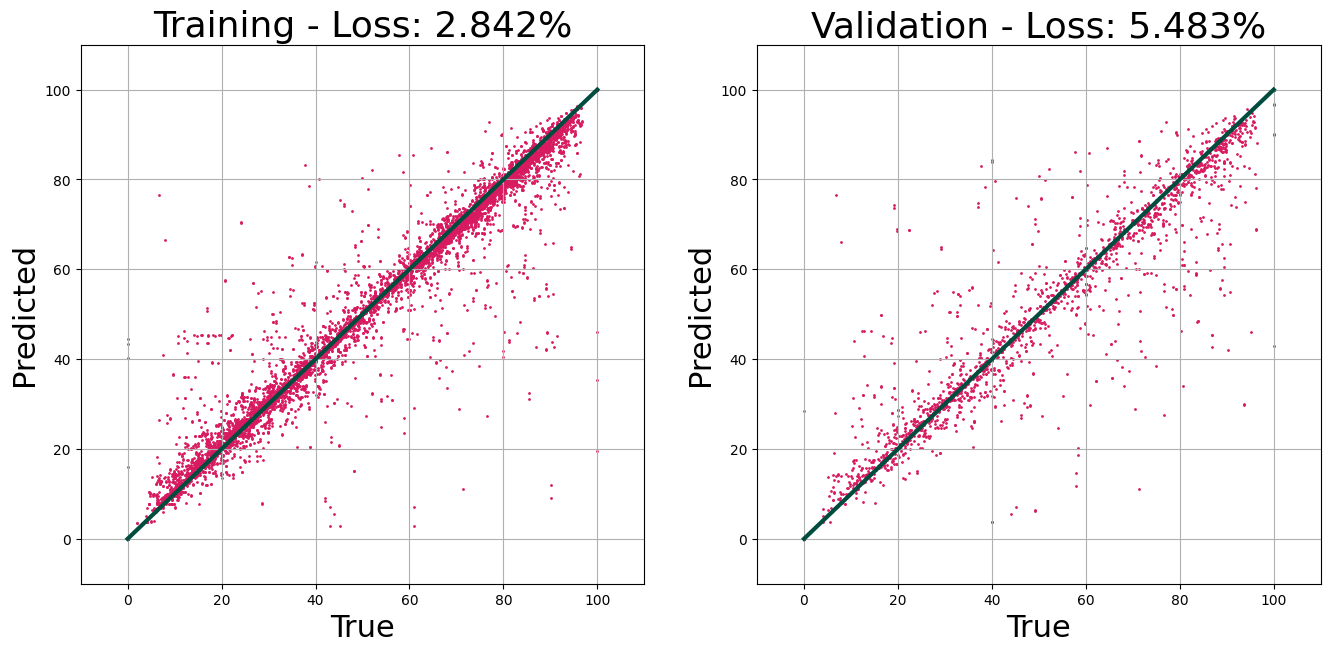

In [ ]:
mask = trues_train != 0.0
loss_train = np.mean(np.abs(preds_train - trues_train))

fig, ax = plt.subplots(1,2, figsize=(16,7))
ax[0].plot([0, 100], [0, 100], color="#004D40", linewidth=3)
ax[0].scatter(100 * trues_train, 100 * preds_train, color="#D81B60", s=1)
ax[0].set_xlim(-10,110)
ax[0].set_ylim(-10,110)
ax[0].set_xlabel("True", fontsize=22)
ax[0].set_ylabel("Predicted", fontsize=22)
ax[0].set_title(f"Training - Loss: {loss_train*100:.3f}%", fontsize=26)
ax[0].grid()

mask = trues_test != 0.0
loss_test = np.mean(np.abs(preds_test - trues_test))

ax[1].plot([0, 100], [0, 100], color="#004D40", linewidth=3)
ax[1].scatter(100 * trues_test, 100 * preds_test, color="#D81B60", s=1)
ax[1].set_xlim(-10,110)
ax[1].set_ylim(-10,110)
ax[1].set_xlabel("True", fontsize=22)
ax[1].set_ylabel("Predicted", fontsize=22)
ax[1].set_title(f"Validation - Loss: {loss_test*100:.3f}%", fontsize=26)
ax[1].grid()
plt.show()

# Optuna

In [9]:
def objective(trial):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    batch_size = trial.suggest_int("batch_size", 16, 128, step=16)
    lr = trial.suggest_float("lr", 1e-5, 3e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5)

    price_hidden = trial.suggest_categorical("price_hidden", [1, 2, 4, 8, 16, 32, 64])
    token_hidden = trial.suggest_categorical(
        "token_hidden", [64, 128, 256, 512, 1024, 2048, 4096]
    )
    head_hidden = trial.suggest_categorical("head_hidden", [128, 256, 512, 1024])

    dataset = ImagePriceRatingDataset(ratings, images, prices, tokens)
    token_dim = tokens.shape[1]

    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size

    train_dataset, val_dataset = random_split(
        dataset,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42),
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    class ImagePriceModel(nn.Module):
        def __init__(self):
            super().__init__()
            weights = ResNet50_Weights.IMAGENET1K_V2
            image_branch = resnet50(weights=weights)
            self.image_branch = nn.Sequential(*list(image_branch.children())[:-1])

            self.price_branch = nn.Sequential(
                nn.Linear(1, price_hidden),
                nn.ReLU(),
                nn.Linear(price_hidden, price_hidden),
                nn.ReLU(),
            )

            self.token_branch = nn.Sequential(
                nn.Linear(token_dim, token_hidden),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
                nn.Linear(token_hidden, token_hidden),
                nn.ReLU(),
            )

            joint_dim = 2048 + price_hidden + token_hidden
            self.head = nn.Sequential(
                nn.Linear(joint_dim, head_hidden),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
                nn.Linear(head_hidden, head_hidden // 2),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
                nn.Linear(head_hidden // 2, 1),
                nn.Sigmoid(),
            )

        def forward(self, image, price, token):
            img_feat = self.image_branch(image).flatten(1)
            price_feat = self.price_branch(price)
            token_feat = self.token_branch(token)
            x = torch.cat([img_feat, price_feat, token_feat], dim=1)
            return self.head(x)

    model = ImagePriceModel().to(device)
    criterion = nn.L1Loss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_loss = float("inf")
    patience = 5
    bad_epochs = 0

    for epoch in range(20):
        model.train()
        for images_loaded, prices_loaded, tokens_loaded, ratings_loaded in train_loader:
            images_loaded = images_loaded.float().to(device)
            prices_loaded = prices_loaded.float().unsqueeze(1).to(device)
            tokens_loaded = tokens_loaded.float().to(device)
            ratings_loaded = ratings_loaded.float().unsqueeze(1).to(device)

            preds = model(images_loaded, prices_loaded, tokens_loaded)
            loss = criterion(preds, ratings_loaded)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images_loaded, prices_loaded, tokens_loaded, ratings_loaded in val_loader:
                images_loaded = images_loaded.float().to(device)
                prices_loaded = prices_loaded.float().unsqueeze(1).to(device)
                tokens_loaded = tokens_loaded.float().to(device)
                ratings_loaded = ratings_loaded.float().unsqueeze(1).to(device)

                preds = model(images_loaded, prices_loaded, tokens_loaded)
                loss = criterion(preds, ratings_loaded)
                val_loss += loss.item()

        val_loss /= len(val_loader)

        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            break

    return best_val_loss


sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(
    study_name="Ratings Identifier",
    direction="minimize",
    sampler=sampler,
)
study.optimize(objective, n_trials=500, show_progress_bar=True, n_jobs=1)

[I 2026-06-07 22:33:58,530] A new study created in memory with name: Ratings Identifier
Best trial: 0. Best value: 0.132839:   0%|          | 1/500 [04:16<35:33:29, 256.53s/it]

[I 2026-06-07 22:38:15,062] Trial 0 finished with value: 0.13283852771634147 and parameters: {'batch_size': 48, 'lr': 0.0022648248189516837, 'weight_decay': 0.0008471801418819979, 'dropout_rate': 0.3394633936788146, 'price_hidden': 8, 'token_hidden': 64, 'head_hidden': 512}. Best is trial 0 with value: 0.13283852771634147.


Best trial: 1. Best value: 0.116594:   0%|          | 2/500 [09:08<38:24:12, 277.62s/it]

[I 2026-06-07 22:43:07,436] Trial 1 finished with value: 0.11659375968433562 and parameters: {'batch_size': 48, 'lr': 8.082071885709241e-05, 'weight_decay': 6.672367170464208e-05, 'dropout_rate': 0.41407038455720546, 'price_hidden': 16, 'token_hidden': 128, 'head_hidden': 1024}. Best is trial 1 with value: 0.11659375968433562.


Best trial: 2. Best value: 0.110634:   1%|          | 3/500 [13:00<35:26:18, 256.70s/it]

...

Best trial: 35. Best value: 0.105555:  16%|█▌        | 78/500 [1:00:56<9:10:23, 78.25s/it]

[I 2026-06-07 23:34:55,246] Trial 77 finished with value: 0.10669821185561326 and parameters: {'batch_size': 80, 'lr': 0.0003795682211752848, 'weight_decay': 1.9282770825581103e-06, 'dropout_rate': 0.20444981282348054, 'price_hidden': 16, 'token_hidden': 4096, 'head_hidden': 256}. Best is trial 35 with value: 0.10555478362810045.


Best trial: 35. Best value: 0.105555:  16%|█▌        | 78/500 [1:01:52<5:34:45, 47.60s/it]

[W 2026-06-07 23:35:51,091] Trial 78 failed with parameters: {'batch_size': 80, 'lr': 0.00011166396662747787, 'weight_decay': 5.8741674609224305e-06, 'dropout_rate': 0.1325615456945645, 'price_hidden': 16, 'token_hidden': 4096, 'head_hidden': 1024} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/jakob/.pyenv/versions/3.13.12/lib/python3.13/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/tmp/ipykernel_25961/2449561952.py", line 82, in objective
    images_loaded = images_loaded.float().to(device)
KeyboardInterrupt
[W 2026-06-07 23:35:51,093] Trial 78 failed with value None.


KeyboardInterrupt: 

In [ ]:
import os
import pandas as pd

output_path = "optuna_best_hyperparameters.csv"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

best_row = {
    "study_name": study.study_name,
    "trial_number": study.best_trial.number,
    "best_value": study.best_value,
    **study.best_params,
}

pd.DataFrame([best_row]).to_csv(output_path, index=False)
print(f"Saved best hyperparameters to: {output_path}")

In [ ]:
def objective(trial):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # optimizer / training params
    batch_size = trial.suggest_int("batch_size", 16, 128, step=16)
    lr = trial.suggest_float("lr", 1e-5, 3e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)

    # architecture search space (fixed maximums; unused layer params are ignored)
    MAX_PRICE_LAYERS = 3
    MAX_TOKEN_LAYERS = 4
    MAX_HEAD_LAYERS = 4

    n_price_layers = trial.suggest_int("n_price_layers", 1, MAX_PRICE_LAYERS)
    n_token_layers = trial.suggest_int("n_token_layers", 1, MAX_TOKEN_LAYERS)
    n_head_layers = trial.suggest_int("n_head_layers", 1, MAX_HEAD_LAYERS)

    # per-layer size choices (names must be stable across trials)
    price_layer_choices = [8, 16, 32, 64]
    token_layer_choices = [64, 128, 256, 512, 1024]
    head_layer_choices = [128, 256, 512, 1024]

    price_sizes = [trial.suggest_categorical(f"price_size_{i}", price_layer_choices) for i in range(MAX_PRICE_LAYERS)]
    token_sizes = [trial.suggest_categorical(f"token_size_{i}", token_layer_choices) for i in range(MAX_TOKEN_LAYERS)]
    head_sizes = [trial.suggest_categorical(f"head_size_{i}", head_layer_choices) for i in range(MAX_HEAD_LAYERS)]

    # other head-wide param (optional)
    final_head_fc = trial.suggest_categorical("final_head_fc", [True, False])

    # dataset + dims
    dataset = ImagePriceRatingDataset(ratings, images, prices, tokens)
    token_dim = tokens.shape[1]

    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(
        dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42)
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # helper to build MLPs for variable depths
    def build_mlp(in_dim, sizes, n_layers, dropout):
        layers = []
        if n_layers <= 0:
            return nn.Identity()
        # first layer
        layers.append(nn.Linear(in_dim, sizes[0]))
        layers.append(nn.ReLU())
        for i in range(1, n_layers):
            layers.append(nn.Dropout(dropout))
            layers.append(nn.Linear(sizes[i - 1], sizes[i]))
            layers.append(nn.ReLU())
        return nn.Sequential(*layers)

    class ImagePriceModel(nn.Module):
        def __init__(self):
            super().__init__()
            weights = ResNet50_Weights.IMAGENET1K_V2
            image_branch = resnet50(weights=weights)
            self.image_branch = nn.Sequential(*list(image_branch.children())[:-1])  # [B,2048]

            self.price_branch = build_mlp(1, price_sizes, n_price_layers, dropout_rate)
            self.token_branch = build_mlp(token_dim, token_sizes, n_token_layers, dropout_rate)

            # determine price and token output dims (last layer size of each branch)
            price_out = price_sizes[n_price_layers - 1]
            token_out = token_sizes[n_token_layers - 1]
            joint_dim = 2048 + price_out + token_out

            # build head
            head_layers = []
            if n_head_layers == 1:
                head_layers.append(nn.Linear(joint_dim, 1))
            else:
                head_layers.append(nn.Linear(joint_dim, head_sizes[0]))
                head_layers.append(nn.ReLU())
                head_layers.append(nn.Dropout(dropout_rate))
                for i in range(1, n_head_layers):
                    prev = head_sizes[i - 1] if i - 1 < len(head_sizes) else head_sizes[-1]
                    curr = head_sizes[i] if i < len(head_sizes) else head_sizes[-1]
                    head_layers.append(nn.Linear(prev, curr))
                    if i != n_head_layers - 1:
                        head_layers.append(nn.ReLU())
                        head_layers.append(nn.Dropout(dropout_rate))
                # final mapping to 1 if final_head_fc True else reuse last linear
                if final_head_fc:
                    head_layers.append(nn.Linear(head_sizes[n_head_layers - 1], 1))
                else:
                    # ensure final linear to 1 exists
                    head_layers.append(nn.Linear(head_sizes[n_head_layers - 1], 1))
            head_layers.append(nn.Sigmoid())
            self.head = nn.Sequential(*head_layers)

        def forward(self, image, price, token):
            img_feat = self.image_branch(image).flatten(1)
            price_feat = self.price_branch(price)
            token_feat = self.token_branch(token)
            x = torch.cat([img_feat, price_feat, token_feat], dim=1)
            return self.head(x)

    model = ImagePriceModel().to(device)
    criterion = nn.L1Loss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_loss = float("inf")
    patience = 5
    bad_epochs = 0

    for epoch in range(20):
        model.train()
        for images_loaded, prices_loaded, tokens_loaded, ratings_loaded in train_loader:
            images_loaded = images_loaded.float().to(device)
            prices_loaded = prices_loaded.float().unsqueeze(1).to(device)
            tokens_loaded = tokens_loaded.float().to(device)
            ratings_loaded = ratings_loaded.float().unsqueeze(1).to(device)

            preds = model(images_loaded, prices_loaded, tokens_loaded)
            loss = criterion(preds, ratings_loaded)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images_loaded, prices_loaded, tokens_loaded, ratings_loaded in val_loader:
                images_loaded = images_loaded.float().to(device)
                prices_loaded = prices_loaded.float().unsqueeze(1).to(device)
                tokens_loaded = tokens_loaded.float().to(device)
                ratings_loaded = ratings_loaded.float().unsqueeze(1).to(device)

                preds = model(images_loaded, prices_loaded, tokens_loaded)
                loss = criterion(preds, ratings_loaded)
                val_loss += loss.item()

        val_loss /= len(val_loader)

        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            break

    return best_val_loss



sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(
    study_name="Ratings Identifier",
    direction="minimize",
    sampler=sampler,
)
study.optimize(objective, n_trials=500, show_progress_bar=True, n_jobs=1)

In [ ]:
import os
import pandas as pd

output_path = "optuna_best_hyperparameters2.csv"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

best_row = {
    "study_name": study.study_name,
    "trial_number": study.best_trial.number,
    "best_value": study.best_value,
    **study.best_params,
}

pd.DataFrame([best_row]).to_csv(output_path, index=False)
print(f"Saved best hyperparameters to: {output_path}")